# Progetto del corso - Web Data Science - a.a. 2024/2025

# Membri del gruppo numero-gruppo

Il gruppo Martina De Geronimo, Giulia Cattin è composto da:

*   **Giulia Cattin:** matricola 207355, email 361205@studenti.unimore.it
*   **Martina De Geronimo:** matricola 202358, email 359570@studenti.unimore.it


# Materiale del progetto

Il materiale del progetto è disponibile sulla pagina Moodle del corso e contiene:

* *dataset.csv*: è il dataset del progetto. Contiene valori non numerici e deve essere utilizzato per realizzare le fasi 1 e 2 del progetto  
* *dataset_descrizione.txt:* un file di testo con la descrizione delle variabili (le colonne) del dataset

**Attenzione:** I valori non numerici presenti nei precedenti due dataset sono stati convertiti in valori numerici, così da poter essere utilizzati per realizzare la fase 3 del progetto

**Attenzione 2:** rinominare il notebook prima della consegna inserendo il nome o numero del proprio gruppo in 'Progetto_WebDataScience_gruppo-n.ipynb'.

**Importante** per la fase 3 creare la separazione train-test utilizzando il seguente comando:
```python
X = df.drop('click', axis=1)
y = df['click']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=XXX)
```
dove df sarà il vostro dataframe e al posto di XXX dovrete mettere il valore medio delle vostre matricole (come numero intero).

# Preparazione dell'ambiente

Prima di iniziare questa parte dobbiamo preparare l'ambiente Colab importando **Pandas**, **Seaborn** e **Scikit-learn**, le librerie Python che abbiamo visto in questo corso.

```python
# Pandas
import pandas as pd
import numpy as np

# Seaborn
import seaborn as sns
import matplotlib.pyplot as plt

# Scikit-learn
from sklearn import svm, tree
from sklearn.metrics import *
from sklearn.model_selection import train_test_split

# riportare nella cella di codice seguente ed eseguire:
# da questo punto in poi le estensioni Pandas, Seaborn e Scikit-learn
# sone attive e possiamo usarle per tutto il resto del notebook.
```

In [1]:
# Pandas
import pandas as pd
import numpy as np

# Seaborn
import seaborn as sns
import matplotlib.pyplot as plt

# Scikit-learn
from sklearn import svm, tree
from sklearn.metrics import *
from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier #lo abbiamo aggiunto per poter eseguire il random forest (con AI)

# **FASE 1**

In [3]:
# Carichiamo il dataset
df = pd.read_csv('/content/sample_data/dataset.csv')

## Analisi preliminare: esaminiamo le caratteristiche del dataset.

In [4]:
df.head()

,id,full_name,age,gender,device_type,ad_position,browsing_history,time_of_day,click
0,670,User670,22.0,NaN,Desktop,Top,Shopping,Afternoon,1
1,3044,User3044,NaN,Male,Desktop,Top,NaN,NaN,1
2,5912,User5912,41.0,Non-Binary,NaN,Side,Education,Night,1
3,5418,User5418,34.0,Male,NaN,NaN,Entertainment,Evening,1
4,9452,User9452,39.0,Non-Binary,NaN,NaN,Social Media,Morning,0


In [5]:
# Esclusione id e full_name perchè sono variabili identificative ma non predittive
df=df.drop(columns=['id','full_name'])

### 1. Qual è la struttura del dataset?

In [6]:
# Determinare numero di righe e di colonne
num_righe = df.shape[0]
num_colonne = df.shape[1]
print("Numero righe:", num_righe)
print("Numero colonne:", num_colonne)

Numero righe: 10000
Numero colonne: 7


**Risposta 1:** Il dataset presenta 10000 righe e 7 colonne, di cui una *('click')* è la variabile target; ciò che significa che ci sono 10.000 utenti con 9 caratteristiche registrate.

In [7]:
# Descrizione statistica delle colonne numeriche
print("\nDescrizione variabili numeriche:")
print(df.describe())


Descrizione variabili numeriche:
               age         click
count  5234.000000  10000.000000
mean     40.197363      0.650000
std      13.126420      0.476993
min      18.000000      0.000000
25%      29.000000      0.000000
50%      39.500000      1.000000
75%      52.000000      1.000000
max      64.000000      1.000000


* La colonna age ha 5234 valori non nulli su 10.000 → significa che circa metà dei dati di età sono mancanti.
* La media dell'età è 40.19 anni, con un minimo di 18 e un massimo di 64.
* La colonna click è binaria (0 o 1) con una media di 0.65, quindi il 65% degli utenti ha cliccato.

Questa cella ci aiuta a capire la distribuzione e i valori anomali.
Ad esempio, ci accorgiamo che age ha solo 5234 valori, quindi mancano molti dati

### 2. Quante sono le variabili categoriche e numeriche?

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               5234 non-null   float64
 1   gender            5307 non-null   object 
 2   device_type       8000 non-null   object 
 3   ad_position       8000 non-null   object 
 4   browsing_history  5218 non-null   object 
 5   time_of_day       8000 non-null   object 
 6   click             10000 non-null  int64  
dtypes: float64(1), int64(1), object(5)
memory usage: 547.0+ KB


**Risposta 2:** Il dataset presenta 2 variabili numeriche e 5 categoriche, etichettate come *object*.


### 3. Ci sono valori mancanti? In che percentuale?

In [9]:
print("Percentuale valori mancanti (%):\n")
print(df.isnull().sum()/len(df)*100)

Percentuale valori mancanti (%):

age                 47.66
gender              46.93
device_type         20.00
ad_position         20.00
browsing_history    47.82
time_of_day         20.00
click                0.00
dtype: float64


**Risposta 3:** Al netto della target, tutte le variabili selezionate hanno valori mancanti. In particolare *browsing history, age e gender* presentano circa il 50% di valori missing. Di conseguenza, l'imputazione di queste variabili potrebbe distorcere i risultati, poiché si aggiungerebbero dati non reali che influenzano le conclusioni.

### 4. Quanti livelli presenta ogni variabile? E' opportuno fare degli accorpamenti per migliorare la qualità delle analisi?

In [10]:
df.nunique().reset_index().rename(columns={'index': 'Variabili', 0: 'Livelli'}) #codice trovato con AI

,Variabili,Livelli
0,age,47
1,gender,3
2,device_type,3
3,ad_position,3
4,browsing_history,5
5,time_of_day,4
6,click,2


**Risposta 4:** *Age*, quindi l'età, è l'unica variabile che ha molti valori diversi. Per semplificare l'analisi, potrebbe essere utile suddividerla in fasce di età, ad esempio: 18-25, 26-35, 36-45, ecc. Questo aiuta a capire meglio le tendenze nei dati e rende il modello più efficace.

### 5. Qual è la distribuzione dei livelli per ogni variabile categorica? La numerosità è omogenea?

       gender  count
0      Female   1834
1        Male   1810
2  Non-Binary   1663

------------------------------

  device_type  count
0     Desktop   2754
1      Mobile   2649
2      Tablet   2597

------------------------------

  ad_position  count
0      Bottom   2817
1         Top   2597
2        Side   2586

------------------------------

  browsing_history  count
0    Entertainment   1175
1     Social Media   1054
2        Education   1029
3         Shopping    984
4             News    976

------------------------------

  time_of_day  count
0     Morning   2126
1   Afternoon   2016
2     Evening   1958
3       Night   1900

------------------------------



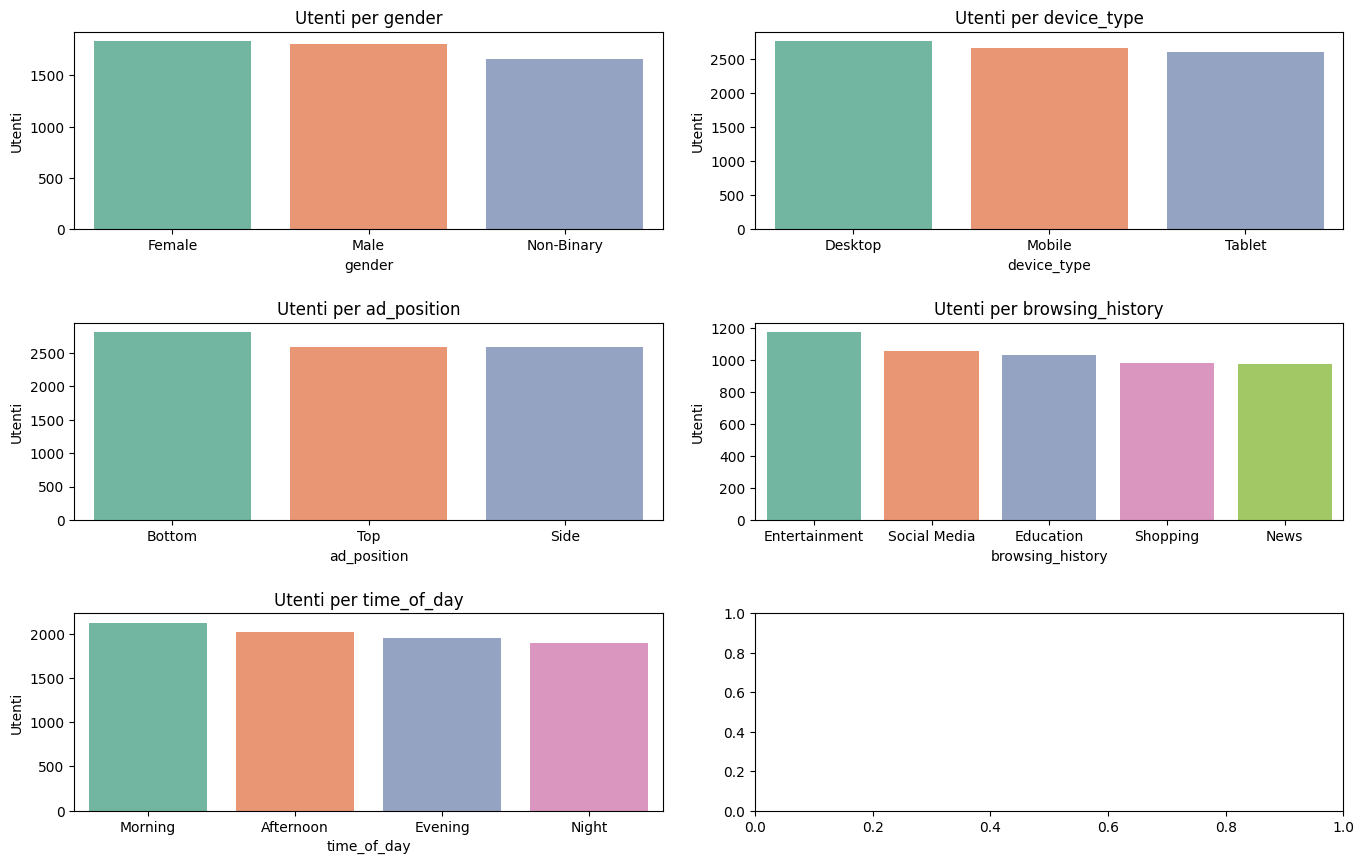

In [11]:
#Codice trovato con l'aiuto dell'AI

# Selezioniamo solo le colonne categoriche
categorical_cols = df.select_dtypes(include=['object','category']).columns

# Creiamo una serie di grafici organizzati in una griglia, in modo da:
# visualizzare più variabili categoriche contemporaneamente
# confrontare facilmente la distribuzione delle variabili categoriche
righe_griglia = (len(categorical_cols) + 1) // 2  # Numero di righe nella griglia
fig, axes = plt.subplots(righe_griglia, 2, figsize=(14, 3 * righe_griglia))

# Creiamo un barplot per ogni colonna categorica
for i, col in enumerate(categorical_cols):
    category_counts = df[col].value_counts()
    sns.barplot(x=category_counts.index, y=category_counts.values,  hue=category_counts.index, palette='Set2', ax=axes.flatten()[i])
    print(category_counts.reset_index())
    print("\n" + "-"*30 + "\n")
    axes.flatten()[i].set_title(f'Utenti per {col}', fontsize=12)
    axes.flatten()[i].set_xlabel(col, fontsize=10)
    axes.flatten()[i].set_ylabel('Utenti', fontsize=10)

# Aggiunta spazi per migliorare la leggibilità
plt.tight_layout(pad=2)
plt.show()

**Risposta 5:** Dai barplot si evince che non ci sono profondi squilibri tra le classi di ogni variabile

### 6. Qual è la distribuzione dell'Età?

Osserviamo la distribuzione dell'età per capire quali fasce di età sono rappresentate e se le fasce di età sono omogenee.

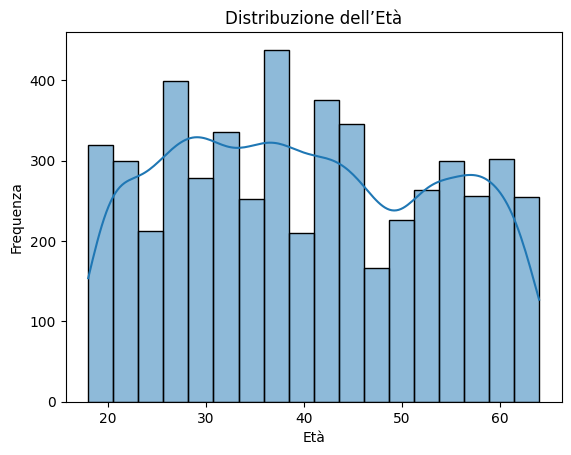

In [12]:
sns.histplot(df['age'], kde=True, )
plt.title('Distribuzione dell’Età')
plt.xlabel('Età')
plt.ylabel('Frequenza')
plt.show()

**Risposta 6:** L'età è distribuita su un range tra 18 e 64 anni, senza una concentrazione estrema in una singola fascia.

### 7. Quale fascia di età è più propensa a cliccare su un banner pubblicitario?

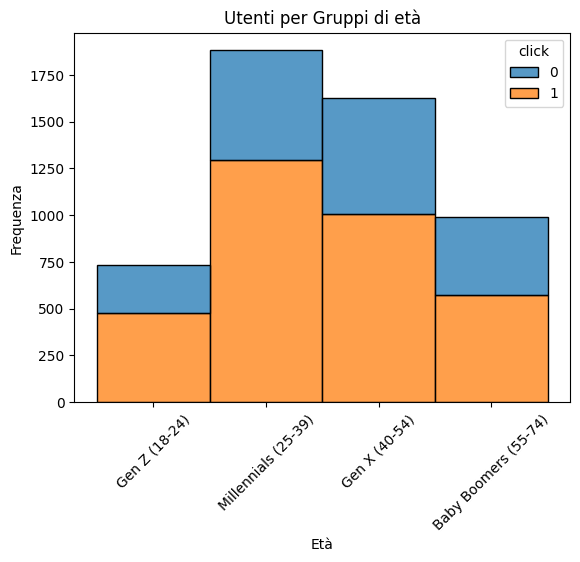

In [13]:
#trasformiamo la variabile numerica "age" in una variabile categorica "age_group"
#codice trovato con l'aiuto dell'AI

estremi = [17, 24, 39, 54, 75]  # Aggiornamento dei bin per gruppi generazionali
etichette = ["Gen Z (18-24)", "Millennials (25-39)", "Gen X (40-54)", "Baby Boomers (55-74)" ] # Assegna etichette a ciascun intervallo
df["age_group"] = pd.cut(df["age"], bins=estremi, labels=etichette) #Creazione della nuova colonna age_group: ora, ogni utente avrà un'etichetta generazionale invece di un numero specifico per l’età

sns.histplot(data=df, x='age_group', hue='click', multiple='stack')

#Personalizzazione del grafico
plt.title('Utenti per Gruppi di età')
plt.xlabel('Età')
plt.ylabel('Frequenza')
plt.xticks(rotation=45) # Ruota le etichette dell’asse X di 45° per evitare sovrapposizioni
plt.show()

Il grafico mostra la distribuzione degli utenti per fascia d'età (Gen Z, Millennials, Gen X, Baby Boomers) e il loro comportamento rispetto ai click sugli annunci (click=0 e click=1).

**Passo successivo:**

Calcoliamo il tasso di click per ogni fascia d'età, indipendentemente dal numero totale di utenti, in modo tale da confrontare le generazioni senza farci influenzare dal fatto che ci siano più Millennials nel dataset.

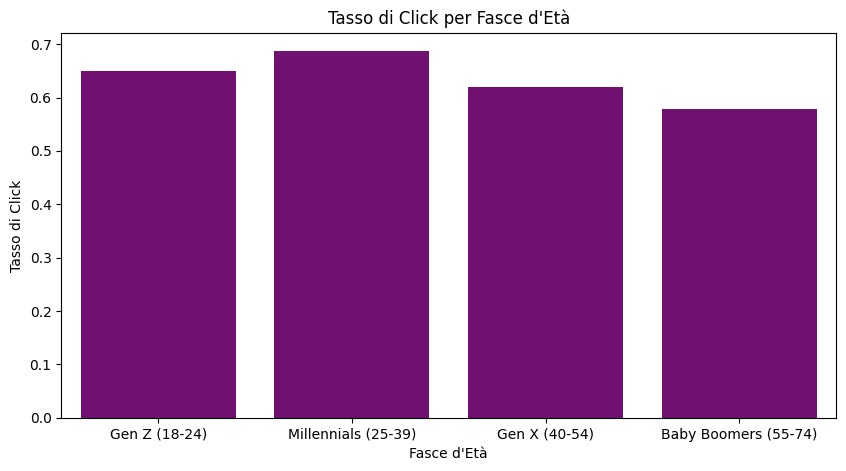


Tasso di Click per Fasce d'Età:

 age_group
Gen Z (18-24)           0.648980
Millennials (25-39)     0.687035
Gen X (40-54)           0.619692
Baby Boomers (55-74)    0.578629
Name: click, dtype: float64


In [14]:
# Calcola il tasso di click per ogni fascia
click_fasce = df.groupby("age_group",observed=True)["click"].mean()

# Creazione del grafico per visualizzare il CTR in base alle fasce d'età
plt.figure(figsize=(10, 5))
sns.barplot(x=click_fasce.index, y=click_fasce.values,color="purple") # index sono le categorie, values sono i tassi di click

plt.title("Tasso di Click per Fasce d'Età")
plt.ylabel("Tasso di Click")
plt.xlabel("Fasce d'Età")
plt.show()
# Stampa i valori di tasso di click per ogni fascia di età
print("\nTasso di Click per Fasce d'Età:\n\n", click_fasce)

**Risposta 7:**

* Millennials (25-39) e Gen Z (18-24) sono i target migliori per gli annunci pubblicitari, poiché hanno il tasso di click più alto (rispettivamente 68.7% e 64.9%).
* Gen X è un target intermedio, con una discreta propensione al click.
* I Baby Boomers sono il gruppo meno reattivo agli annunci pubblicitari online.

### 8. Qual è la distribuzione della variabile target? C'è equilibrio tra le due classi?

Vogliamo capire quanti utenti hanno cliccato (click = 1) e quanti non hanno cliccato (click = 0), e se queste due classi sono rappresentate in modo equilibrato nel dataset.

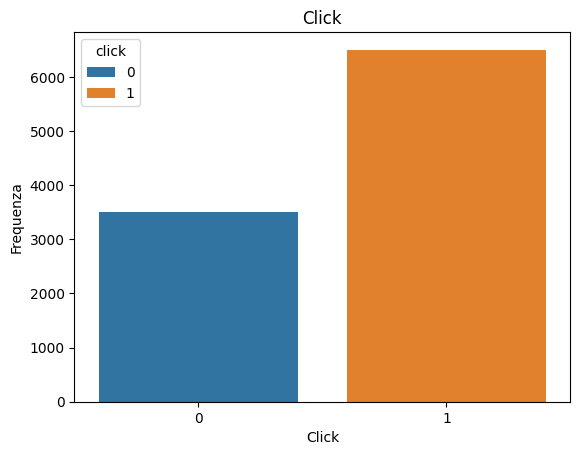

In [15]:
sns.countplot(x='click', hue='click', data=df)
figsize=(3,3)
plt.title('Click')
plt.xlabel('Click')
plt.ylabel('Frequenza')
plt.show()

**Risposta 8:** I due livelli della classe target sono sbilanciati: troviamo infatti 3500 *non-click*, che è solo il 35% del totale delle osservazioni.

# **FASE 2**: visualizzazione delle relazioni tra le variabili all'interno dei dati

### 1. Che correlazione c'è tra età e le altre variabili? L'età varia a seconda dei valori delle variabili categoriche? Ad esempio, l'età media delle persone che navigano su Social Media è più bassa rispetto a chi legge News?

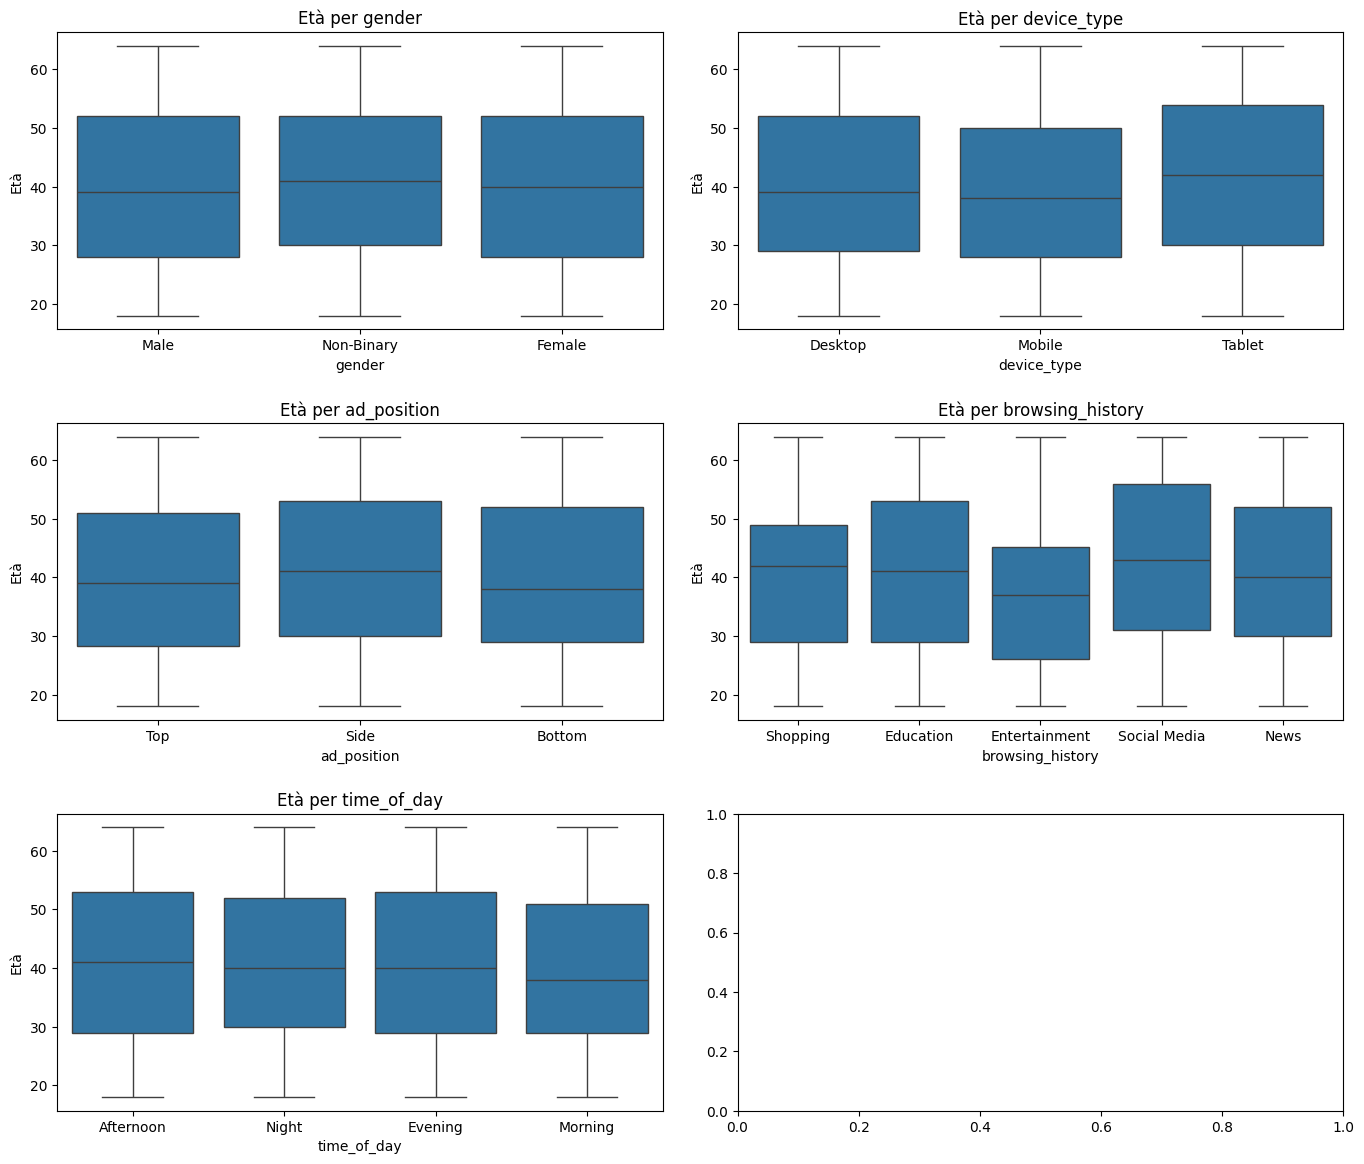

In [16]:
# Creazione griglia per grafici per poterli confrontare subito(AI)
fig, axes = plt.subplots(righe_griglia, 2, figsize=(14, 4 * righe_griglia))

# Creazione Barplot per ogni variabile categorica (AI)
for i, col in enumerate(categorical_cols):
    sns.boxplot(x=col, y='age', data=df, ax=axes.flatten()[i])
    axes.flatten()[i].set_title(f'Età per {col}', fontsize=12)
    axes.flatten()[i].set_xlabel(col, fontsize=10)
    axes.flatten()[i].set_ylabel('Età', fontsize=10)

# Aggiunta spazi per migliore leggibilità (AI)
plt.tight_layout(pad=2)
plt.show()

**Risposta 1:** L'età media sembra non variare in maniera significativa, cosí come la distriuzione. Non sono presenti outlier (tutti i valori sono contenuti dentro i limiti definiti dai baffi e non ci sono punti isolati sopra o sotto i baffi).

### 2. Come cambia la distribuzione della classe target se raggruppiamo gli utenti per ogni variabile categorica? Ad esempio: gli utenti che usano il telefono sono più predisposti a cliccare un banner?

Analizziamo la relazione tra la variabile target (click) e le altre variabili categoriche.


Tasso di Click per gender:

        gender     click
1        Male  0.658011
0      Female  0.657579
2  Non-Binary  0.632592

Tasso di Click per device_type:

   device_type     click
0     Desktop  0.664125
2      Tablet  0.648055
1      Mobile  0.633447

Tasso di Click per ad_position:

   ad_position     click
0      Bottom  0.687256
2         Top  0.634963
1        Side  0.631477

Tasso di Click per browsing_history:

   browsing_history     click
1    Entertainment  0.687660
3         Shopping  0.645325
4     Social Media  0.635674
0        Education  0.627794
2             News  0.591189

Tasso di Click per time_of_day:

   time_of_day     click
0   Afternoon  0.685516
2     Morning  0.665099
1     Evening  0.629724
3       Night  0.624737


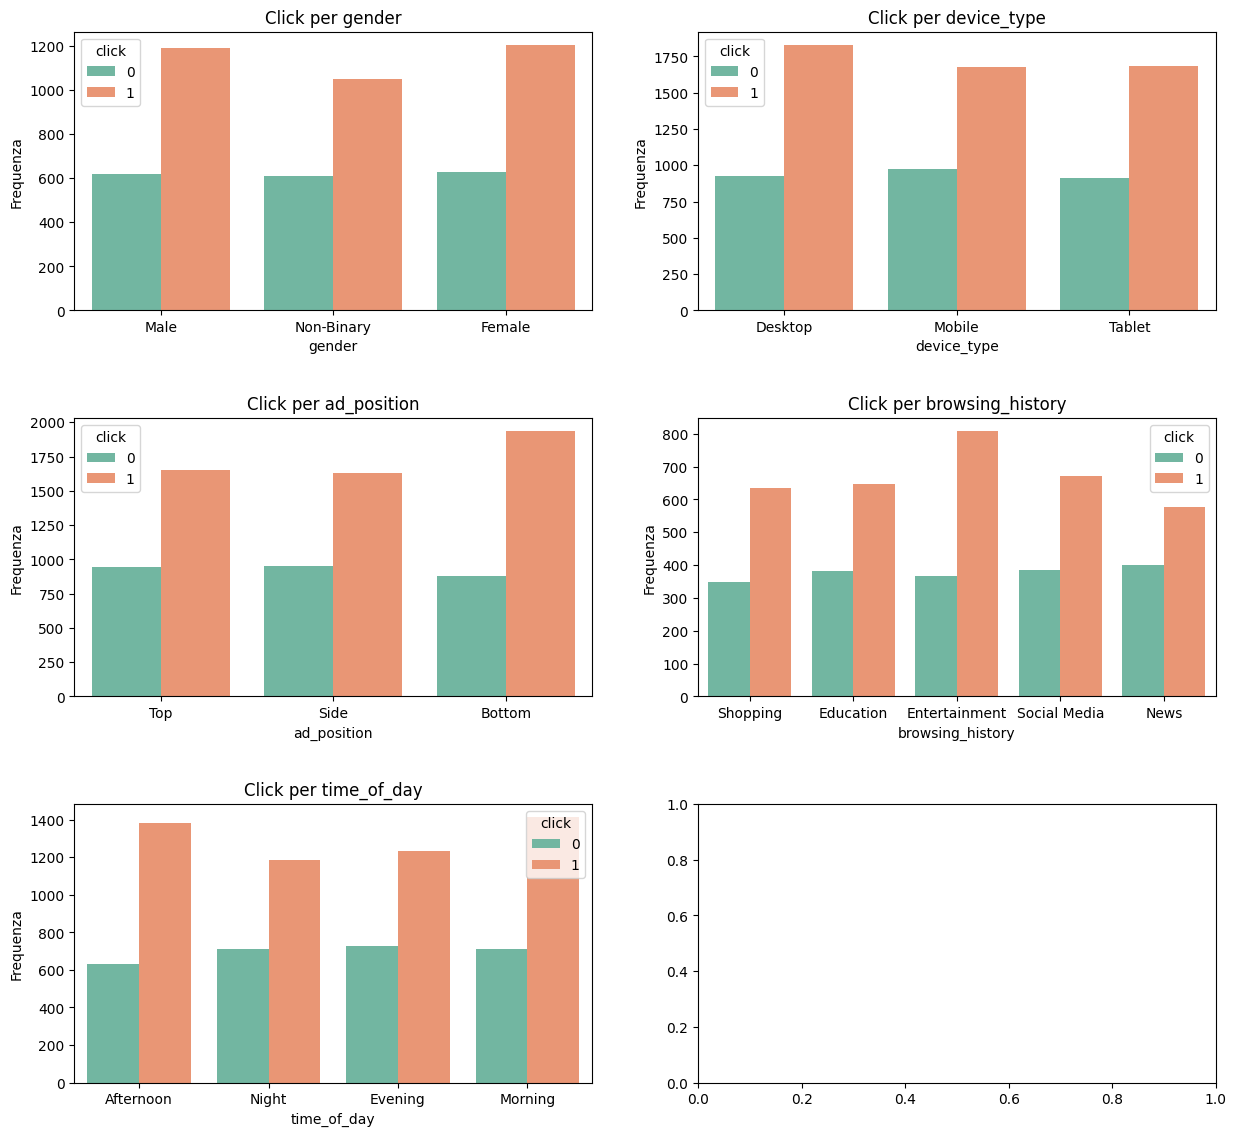

In [17]:
# Creazione griglia per grafici (AI)
righe_griglia = (len(categorical_cols) + 1) // 2
fig, axes = plt.subplots(righe_griglia, 2, figsize=(13, 4 * righe_griglia))

# Per ogni variabile categorica, faccio un grafico di frequenza della classe target
for i, col in enumerate(categorical_cols):
    sns.countplot(x=col, hue='click', data=df, ax=axes.flatten()[i], palette='Set2')
    axes.flatten()[i].set_title(f'Click per {col}', fontsize=12)
    axes.flatten()[i].set_xlabel(col, fontsize=10)
    axes.flatten()[i].set_ylabel('Frequenza', fontsize=10)
    print(f"\nTasso di Click per {col}:\n\n",df.groupby(col, observed=True)["click"].mean().reset_index().sort_values(by="click", ascending=False))

# Aggiunta spazi per migliore leggibilità
plt.tight_layout(pad=3)
plt.show()

**Risposta 2:** Gli utenti sembrano più proni al click di un banner se sono Millenials, se il banner si trova in basso e/o se hanno consumato un contenuto *'Entertainment'* precedentemente. Il tasso di click non sembra variare significativamente tra le classi di genere (*Male,Female,Non-Binary*), mostrando bassa correlazione con la variabile target.

### 3. Quale fascia di età è più attiva in ogni fascia di orario?

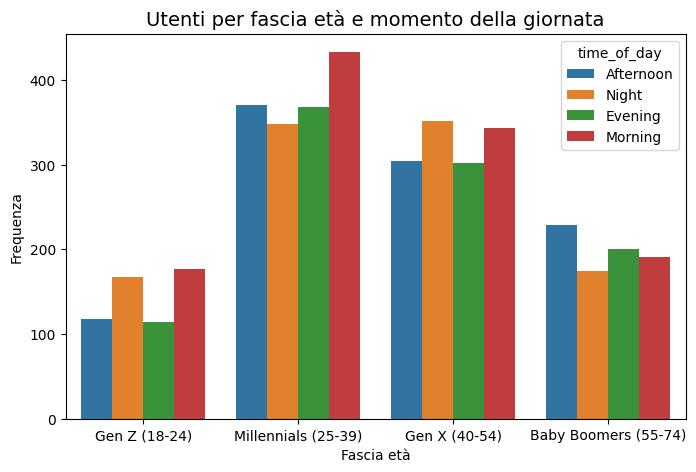

In [18]:
plt.figure(figsize=(8, 5))
sns.countplot(x='age_group', hue='time_of_day', data=df)
plt.title('Utenti per fascia età e momento della giornata', fontsize=14)
plt.ylabel('Frequenza')
plt.xlabel('Fascia età')
plt.show()

**Risposta 3:**

* I Millennials anni sono gli utenti più attivi, soprattutto al mattino.

* I Baby Boomers sono il gruppo di utenti la cui attività è distribuita abbastanza uniformemente tra le diverse fasce orarie

* I Gen X sono più attivi la sera (Evening)

* I Gen Z sono i meno attivi in tutte le fasce orarie

### 4. Come sono correlate le variabili tra di loro? Ipotesi: Se un utente usa il telefono (device_type=Mobile), è più probabile che abbia visitato Social Media prima di vedere la pubblicità?

Esistono schemi tra tipo di dispositivo, fascia oraria, genere e abitudini di navigazione?

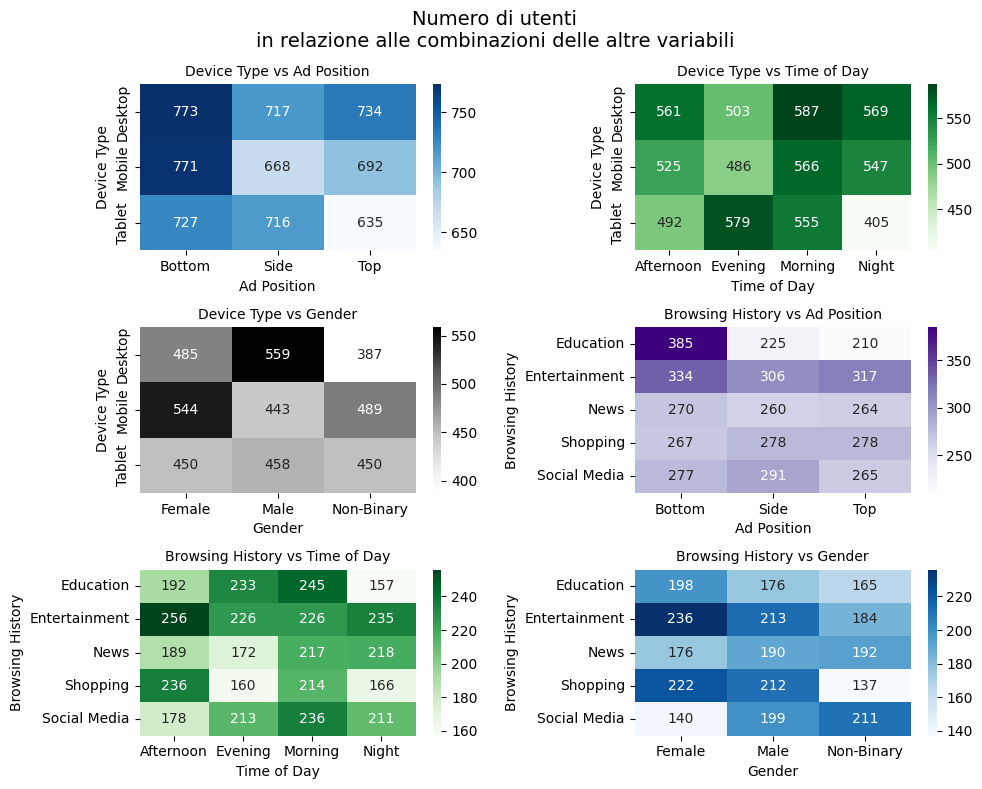

In [19]:
# Le seguenti righe creano delle tabelle di contingenza:
# mostrano quante volte si verifica una combinazione di valori tra due variabili.
# codice trovato con l'aiuto dell'AI
grafico1 = pd.crosstab(df['device_type'], df['ad_position']) #conta il numero di osservazioni (utenti) per ogni combinazione di due variabili categoriche.
grafico2 = pd.crosstab(df['device_type'], df['time_of_day'])
grafico3 = pd.crosstab(df['device_type'], df['gender'])
grafico4 = pd.crosstab(df['browsing_history'], df['ad_position'])
grafico5 = pd.crosstab(df['browsing_history'], df['time_of_day'])
grafico6 = pd.crosstab(df['browsing_history'], df['gender'])

# Creazione della Griglia per i Grafici
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(10, 8))
fig.suptitle("Numero di utenti\nin relazione alle combinazioni delle altre variabili", fontsize=14)

axes = axes.flatten()

# Create heatmaps
sns.heatmap(grafico1, annot=True, cmap="Blues", fmt='d', ax=axes[0])
axes[0].set_title("Device Type vs Ad Position", fontsize=10)
axes[0].set_xlabel("Ad Position")
axes[0].set_ylabel("Device Type")

sns.heatmap(grafico2, annot=True, cmap="Greens", fmt='d', ax=axes[1])
axes[1].set_title("Device Type vs Time of Day", fontsize=10)
axes[1].set_xlabel("Time of Day")
axes[1].set_ylabel("Device Type")

sns.heatmap(grafico3, annot=True, cmap="Greys", fmt='d', ax=axes[2])
axes[2].set_title("Device Type vs Gender", fontsize=10)
axes[2].set_xlabel("Gender")
axes[2].set_ylabel("Device Type")

sns.heatmap(grafico4, annot=True, cmap="Purples", fmt='d', ax=axes[3])
axes[3].set_title("Browsing History vs Ad Position", fontsize=10)
axes[3].set_xlabel("Ad Position")
axes[3].set_ylabel("Browsing History")

sns.heatmap(grafico5, annot=True, cmap="Greens", fmt='d', ax=axes[4])
axes[4].set_title("Browsing History vs Time of Day", fontsize=10)
axes[4].set_xlabel("Time of Day")
axes[4].set_ylabel("Browsing History")

sns.heatmap(grafico6, annot=True, cmap="Blues", fmt='d', ax=axes[5])
axes[5].set_title("Browsing History vs Gender", fontsize=10)
axes[5].set_xlabel("Gender")
axes[5].set_ylabel("Browsing History")

# Aggiunta spazi per migliorare leggibilità
plt.tight_layout(h_pad=1, w_pad=2)

plt.show()

**Risposta 4:**

* Device Type vs Ad Position → La posizione dell’annuncio non sembra dipendere dal dispositivo usato dall’utente.

* Device Type vs Time of Day → Il momento della giornata influisce sull’uso del dispositivo:

 * Tablet → Più usato di sera.
 * Desktop → Più attivo nel pomeriggio e al mattino.
 * Mobile → Più omogeneo nell’arco della giornata, ma leggermente più usato al mattino.

* Device Type vs Gender (Tipo di dispositivo vs Genere) → Uomini e donne hanno preferenze diverse per il dispositivo:

 * Gli uomini preferiscono Desktop.
 * Le donne preferiscono Mobile.
 * Il Tablet è usato in modo più equilibrato.

* Browsing History vs Ad Position → Chi naviga su siti di Education vede più spesso annunci in fondo alla pagina.

* Browsing History vs Time of Day

 * Chi visita Social Media e Shopping è più attivo al mattino.
 * Chi legge News ed Education è più attivo la sera.
 * Entertainment è distribuito in modo più omogeneo.

* Browsing History vs Gender

 * Le donne preferiscono Shopping ed Entertainment.
 * Gli uomini leggono più News e usano più Social Media.
 * Gli utenti Non-Binary hanno abitudini più equilibrate tra le categorie.

Si evince che i banner collocati in basso ricevono più interazioni, soprattutto dagli utenti che hanno consumato contenuti di tipo accademico *('Education')*

### 5. Come influiscono le variabili categoriche sul tasso medio di click su un banner? Quali gruppi di utenti (basati su variabili come device_type, browsing_history, time_of_day, ad_position, ecc.) hanno un tasso di click più alto?

Analizziamo quali variabili categoriche influenzano la probabilità che un utente clicchi su un banner pubblicitario.

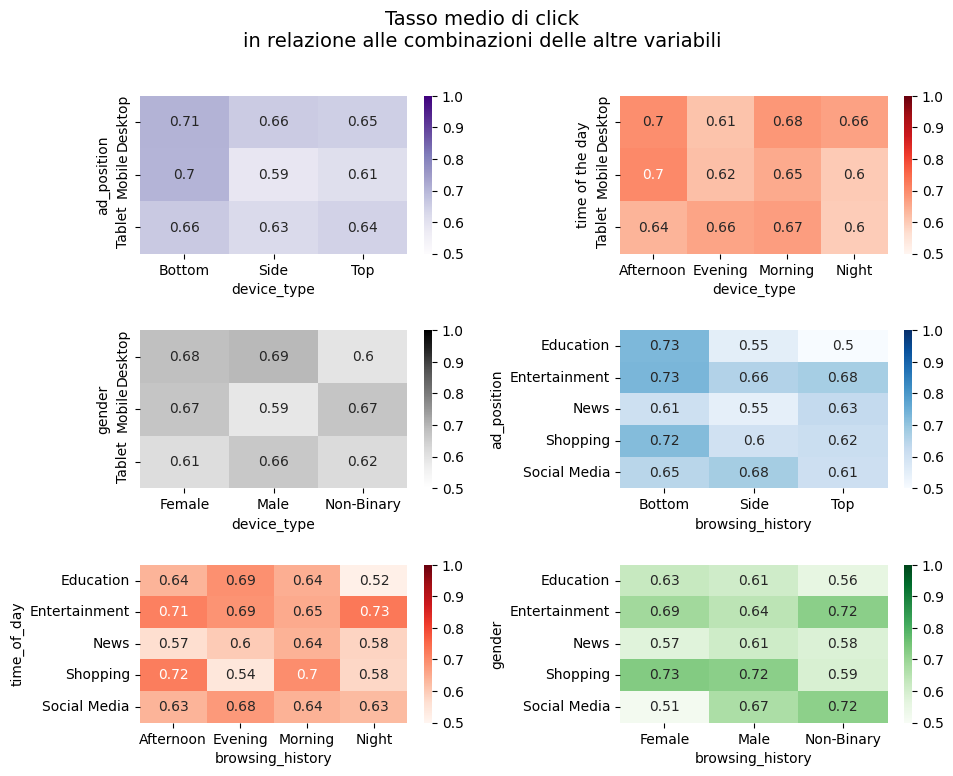

In [20]:
#Codici trovati con l'aiuto dell'AI
#Crea una griglia 3x2 di grafici per visualizzare 6 heatmap
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(10, 8), )
axes = axes.flatten()
fig.suptitle("Tasso medio di click\nin relazione alle combinazioni delle altre variabili", fontsize=14)

#Creazione della prima heatmap
grafico1 = pd.crosstab(df['device_type'], df['ad_position'], values=df['click'], aggfunc='mean')
sns.heatmap(grafico1, annot=True, cmap="Purples", vmin=0.5, vmax=1, ax=axes[0])
axes[0].set_xlabel("device_type")
axes[0].set_ylabel("ad_position")

#Creazione della seconda heatmap
grafico2 = pd.crosstab(df['device_type'], df['time_of_day'], values=df['click'], aggfunc='mean')
sns.heatmap(grafico2, annot=True, cmap="Reds", vmin=0.5, vmax=1, ax=axes[1])
axes[1].set_xlabel("device_type")
axes[1].set_ylabel("time of the day")

#Creazione della terza heatmap
grafico3 = pd.crosstab(df['device_type'], df['gender'], values=df['click'], aggfunc='mean')
sns.heatmap(grafico3, annot=True, cmap="Greys", vmin=0.5, vmax=1, ax=axes[2])
axes[2].set_xlabel("device_type")
axes[2].set_ylabel("gender")

#Creazione della quarta heatmap
grafico4 = pd.crosstab(df['browsing_history'], df['ad_position'], values=df['click'], aggfunc='mean')
sns.heatmap(grafico4, annot=True, cmap="Blues", vmin=0.5, vmax=1, ax=axes[3])
axes[3].set_xlabel("browsing_history")
axes[3].set_ylabel("ad_position")

#Creazione della quinta heatmap
grafico5 = pd.crosstab(df['browsing_history'], df['time_of_day'], values=df['click'], aggfunc='mean')
sns.heatmap(grafico5, annot=True, cmap="Reds", vmin=0.5, vmax=1, ax=axes[4])
axes[4].set_xlabel("browsing_history")
axes[4].set_ylabel("time_of_day")

# Creazione della sesta heatmap
grafico6 = pd.crosstab(df['browsing_history'], df['gender'], values=df['click'], aggfunc='mean')
sns.heatmap(grafico6, annot=True, cmap="Greens", vmin=0.5, vmax=1, ax=axes[5])
axes[5].set_xlabel("browsing_history")
axes[5].set_ylabel("gender")

# Aggiunta spazi per migliore leggibilità
plt.tight_layout(pad=2)
plt.show()

**Risposta 5:** Le Heatmap proposte suggerisco scarsa correlazione tra click e le variabili selezionate in quanto non si evincono pattern di rilievo, tuttavia:
* Per quanto riguarda il tipo di dispositivo, Mobile ottiene proporzionalmente più click, specialmente nel pomeriggio.
* Gli annunci in Bottom hanno il tasso di click più alto.
* Per quanto riguarda l'orario della giornata, pomeriggio e sera hanno il tasso più alto, notte il più basso.
* Chi naviga su Social Media e Entertainment è più propenso a cliccare.
* Le differenze tra uomini, donne e non-binary sono poco significative.

# **FASE 3**

## Soluzione 1: utilizzo tutte le variabili del dataset, ma seleziono le righe (utenti)

In [21]:
#Convertiamo le variabili categoriche in numeri
genders = {"Male": 0, "Female": 1, "Non-Binary": 2}
device_types = {"Mobile": 0, "Desktop": 1, "Tablet": 2}
ad_positions = {"Top": 0, "Side": 1, "Bottom": 2}
time_of_days = {"Morning": 0, "Afternoon": 1, "Evening": 2, "Night": 3}
browsing_histories = {"Social Media": 0, "Shopping": 1, "News": 2, "Entertainment": 3, "Education": 4}
df['gender'] = df['gender'].map(genders)
df['device_type'] = df['device_type'].map(device_types)
df['ad_position'] = df['ad_position'].map(ad_positions)
df['time_of_day'] = df['time_of_day'].map(time_of_days)
df['browsing_history'] = df['browsing_history'].map(browsing_histories)

In [22]:
#Eliminiamo age_group
df1= df.drop(columns=['age_group'])

Abbiamo scelto di rimuovere age_group, per evitare la duplicazione dell'informazione. Dopo vari test, infatti, si è concluso che l'età ha un potere predittivo maggiore delle fasce di età.

In [23]:
# Rimozione di tutte le righe con almeno un valore mancante
df1 = df1.dropna()

Abbiamo scelto di rimuovere le righe con valori mancanti perchè se si riempiono i valori mancanti in modo arbitrario (es. sostituendo NaN con la media o il valore più frequente), si rischia di falsare l’analisi e introdurre distorsioni nei dati.
Rimuovere le righe con `dropna()` assicura che i dati usati nel modello siano reali.

In [24]:
# Controllo numero di righe e colonne
df1.shape

(816, 7)

In [25]:
# Generazione random state per rendere esecuzione replicabile (AI)
rand_state=round((202358+207355)/2)

In [26]:
X1 = df1.drop('click', axis=1)
y1 = df1['click']

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X1, y1, test_size=0.2, random_state=rand_state)


Performance SVM:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        54
           1       0.67      1.00      0.80       110

    accuracy                           0.67       164
   macro avg       0.34      0.50      0.40       164
weighted avg       0.45      0.67      0.54       164

Accuracy: 0.6707317073170732
Precision: 0.6707317073170732
Recall: 1.0

 Confusion Matrix SVM (svm_model1):


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


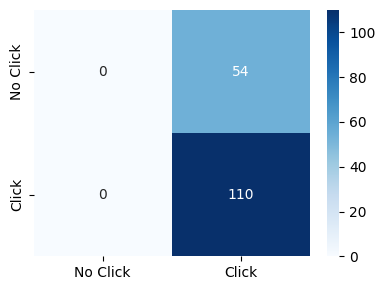

In [28]:
# Modello SVM 1
svm_model1 = svm.SVC(kernel='linear')
svm_model1.fit(X_train, y_train)
y_pred_svm = svm_model1.predict(X_test)
print("\nPerformance SVM:")
print(classification_report(y_test, y_pred_svm))
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall:", recall_score(y_test, y_pred_svm))
cm = confusion_matrix(y_test, y_pred_svm)
# codice trovato con AI
print("\n Confusion Matrix SVM (svm_model1):")
plt.figure(figsize=(4, 3)) #per controllare la dimensione del grafico
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Click', 'Click'], yticklabels=['No Click', 'Click'])
plt.tight_layout() #ottimizza il layout del grafico evitando sovrapposizioni
plt.show()

Il modello sta predicendo solo click=1 per tutti gli utenti.

* La precision per click=0 è 0.00, il che significa che il modello non ha mai previsto "No Click" (0). Tutti i 54 utenti che non hanno cliccato sono stati erroneamente classificati come "Click".
* Il recall per click=1 è 1.00, il che significa che ha identificato correttamente tutti i veri "click".
* L'accuracy è 67%, ma è falsata dal fatto che il modello non riconosce mai "No Click".

Questo potrebbe essere dovuto al fatto che il Dataset è sbilanciato: come abbiamo visto infatti nella fase 1 (domanda 8), i due livelli della classe target sono sbilanciati; troviamo infatti 3500 *non-click*, che è solo il 35% del totale delle osservazioni. L'SVM probabilmente ha imparato a prevedere solo la classe dominante.

Possiamo risolvere il problema provando a bilanciare il dataset con tecniche di undersampling (suggerimento AI).

In [29]:
# Separazione click e non click
click = df1[df1['click'] == 1] # Classe maggioritaria
non_click = df1[df1['click'] == 0] # Classe minoritaria

# Calcolo la dimensione del campione che devo estrarre per equilibrare i livelli della target
dim_campione = len(non_click)

rand_state=round((202358+207355)/2)
# Campionamento della classe maggioritaria (click=1)
click_undersampled = click.sample(dim_campione, random_state=rand_state) #sample(dim_campione, random_state=rand_state) → Estrae un numero di righe pari a dim_campione (cioè len(non_click))

# Unione delle due classi target dopo il campionamento
df1_bilanciato = pd.concat([non_click, click_undersampled])

# Controllo della distribuzione della classe classe target dopo l'undersampling
print("\nDistribuzione della classe target dopo undersampling:\n")
print(df1_bilanciato['click'].value_counts())


Distribuzione della classe target dopo undersampling:

click
0    300
1    300
Name: count, dtype: int64


In [30]:
X1 = df1_bilanciato.drop('click', axis=1)
y1 = df1_bilanciato['click']

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X1, y1, test_size=0.2, random_state=rand_state)

In [32]:
print(f"Numero di osservazioni nel dataset di training: {X_train.shape[0]}")

Numero di osservazioni nel dataset di training: 480



Performance SVM:
              precision    recall  f1-score   support

           0       0.61      0.36      0.45        70
           1       0.43      0.68      0.53        50

    accuracy                           0.49       120
   macro avg       0.52      0.52      0.49       120
weighted avg       0.54      0.49      0.48       120

Accuracy: 0.49166666666666664
Precision: 0.43037974683544306
Recall: 0.68

 Confusion Matrix SVM (svm_model2):


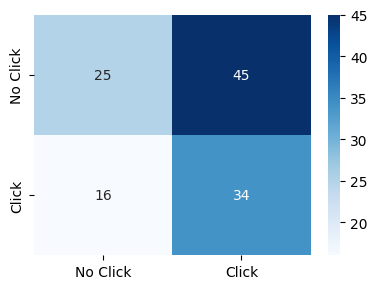

In [33]:
# Modello SVM 2
svm_model2 = svm.SVC(kernel='linear')
svm_model2.fit(X_train, y_train)
y_pred_svm = svm_model2.predict(X_test)
print("\nPerformance SVM:")
print(classification_report(y_test, y_pred_svm))
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall:", recall_score(y_test, y_pred_svm))
cm = confusion_matrix(y_test, y_pred_svm)
print("\n Confusion Matrix SVM (svm_model2):")
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Click', 'Click'], yticklabels=['No Click', 'Click'])
plt.tight_layout()
plt.show()

* Il recall è migliorato, quindi il modello riconosce meglio gli utenti che cliccano, anche se commette ancora troppi falsi positivi (45), come si evince dalla confusion matrix.
* La precisione è ancora bassa, quindi fa ancora molti errori nella previsione dei click.
* L'accuracy non è aumentata molto (49%), indicando che il modello non sta distinguendo bene le due classi.

**NOTA:** Nonostante il bilanciamento della variabile target, il modello non sta riuscendo a distinguere bene tra chi clicca e chi non clicca. Questo potrebbe essere dovuto a:
* I dati non sono abbastanza distintivi → Le informazioni disponibili (come età, dispositivo usato, cronologia di navigazione) non permettono di distinguere chiaramente chi clicca e chi no. I due gruppi infatti si comportano in modo troppo simile.

* Il dataset potrebbe essere troppo piccolo → Con pochi dati, il modello non riesce a imparare bene le differenze tra gli utenti che cliccano e quelli che non cliccano.


Performance Decision Tree: 

              precision    recall  f1-score   support

           0       0.90      0.66      0.76        70
           1       0.65      0.90      0.76        50

    accuracy                           0.76       120
   macro avg       0.78      0.78      0.76       120
weighted avg       0.80      0.76      0.76       120

Accuracy: 0.7583333333333333
Precision: 0.6521739130434783
Recall: 0.9

 Confusion Matrix Decision Tree (dt_model1):


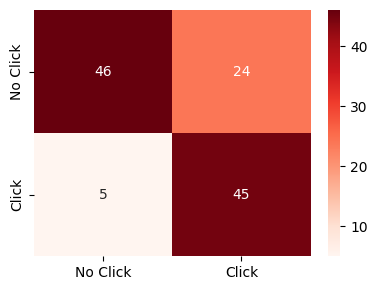

In [34]:
# Modello Decision Tree 1
dt_model1 = tree.DecisionTreeClassifier(random_state=rand_state)
dt_model1.fit(X_train, y_train)
y_pred_dt = dt_model1.predict(X_test)
print("\nPerformance Decision Tree: \n")
print(classification_report(y_test, y_pred_dt))
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
cm = confusion_matrix(y_test, y_pred_dt)
print("\n Confusion Matrix Decision Tree (dt_model1):")
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=['No Click', 'Click'], yticklabels=['No Click', 'Click'])
plt.tight_layout()
plt.show()

* Il Decision Tree è molto più efficace rispetto a SVM nel distinguere chi clicca e chi no.
* Il recall per click=1 è alto (90%), quindi il modello trova quasi tutti gli utenti che cliccano.
* Tuttavia, il modello fa ancora errori nel predire "No Click": il modello infatti commette ancora troppi falsi positivi (24).

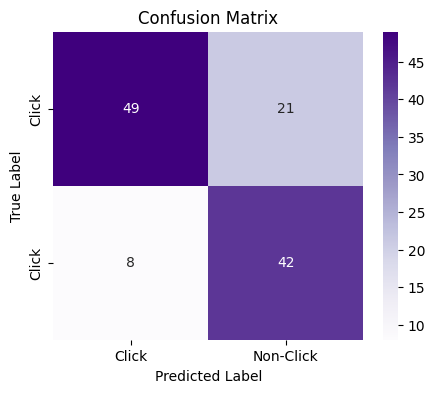

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.70      0.77        70
           1       0.67      0.84      0.74        50

    accuracy                           0.76       120
   macro avg       0.76      0.77      0.76       120
weighted avg       0.78      0.76      0.76       120


Performance Random Forest: 

Accuracy: 0.7583333333333333
Precision: 0.6521739130434783
Recall: 0.9


In [35]:
# Implementazione Random Forest (AI)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=["Click", "Non-Click"], yticklabels=["Click", "Click"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("\nPerformance Random Forest: \n")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))

* L'accuracy è salita a 76%, il che indica un miglioramento significativo rispetto ai risultati precedenti.
* Precisione per click=1 (67%) → Il modello fa ancora qualche errore nel prevedere click=1, ma è migliorato.
* Recall per click=1 (84%) → Il modello è molto bravo a riconoscere chi clicca, trovando l’84% dei click=1.
* La precisione per No Click (0) è 86%, quindi è molto affidabile nel dire quando un utente non cliccherà.
* I falsi negativi sono diminuiti (solo 8 rispetto ai 24 di prima), quindi il modello riconosce meglio i veri click.
* I falsi positivi sono ancora presenti (21), quindi il modello a volte predice erroneamente "Click".

Il Random Forest è più stabile e bilanciato rispetto al Decision Tree, ed è il miglior modello finora; ha infatti un equilibrio migliore tra precisione e recall, quindi è più affidabile nel predire correttamente entrambe le classi.

## Soluzione 2: selezione delle variabili più significative

In [36]:
# Come visto in Fase 1, alcune variabili hanno una densità di valori mancanti alta (circa 50%);
# Per questo motivo le droppiamo

df2=df.drop(columns=['browsing_history','age','age_group','gender'])

In [37]:
df2.shape

(10000, 4)

In [38]:
# Ci sono ancora valori mancanti?
df2.isnull().sum()

,0
device_type,2000
ad_position,2000
time_of_day,2000
click,0


In [39]:
# Imputazione della moda nelle variabili categoriche (AI)

for col in df2.select_dtypes(include=['number']).columns:
    df2[col]= df2[col].fillna(df2[col].mode()[0])

In [40]:
# Verifico di avere imputato i valori mancanti

df2.isnull().sum()

,0
device_type,0
ad_position,0
time_of_day,0
click,0


In [41]:
# Bilanciamento della classe target (AI)

# Separo click e non click
click = df2[df2['click'] == 1] # Classe maggioritaria
non_click = df2[df2['click'] == 0] # Classe minoritaria

# Calcolo la dimensione del campione che devo estrarre per equilibrare i livelli della target
dim_campione = len(non_click)

# Campiono la classe maggioritaria (click=1) (AI)
click_undersampled = click.sample(dim_campione, random_state=rand_state)

# Controllo della distribuzione della classe classe target dopo l'undersampling (AI)
df2_bilanciato = pd.concat([non_click, click_undersampled])

# Controllo della distribuzione della classe classe target dopo l'undersampling (AI)
print("\nDistribuzione della classe Target dopo undersampling:\n")
print(df2_bilanciato['click'].value_counts())


Distribuzione della classe Target dopo undersampling:

click
0    3500
1    3500
Name: count, dtype: int64


In [42]:
# Divido le variabili indipendenti (X) dalla target (y)
X2 = df2.drop('click', axis=1)
y2 = df2['click']

In [43]:
X_train, X_test, y_train, y_test = train_test_split(X2, y2, test_size=0.2, random_state=rand_state)


Performance SVM (svm_model2):
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       724
           1       0.64      1.00      0.78      1276

    accuracy                           0.64      2000
   macro avg       0.32      0.50      0.39      2000
weighted avg       0.41      0.64      0.50      2000

Accuracy: 0.638
Precision: 0.638
Recall: 1.0

 Confusion Matrix SVM:


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


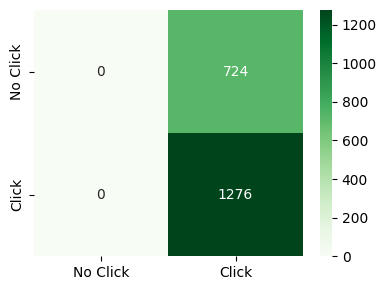

In [44]:
# Modello SVM 3
svm_model3 = svm.SVC(kernel='linear')
svm_model3.fit(X_train, y_train)
y_pred_svm = svm_model3.predict(X_test)
print("\nPerformance SVM (svm_model2):")
print(classification_report(y_test, y_pred_svm))
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall:", recall_score(y_test, y_pred_svm))
cm = confusion_matrix(y_test, y_pred_svm)
print("\n Confusion Matrix SVM:")
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=['No Click', 'Click'], yticklabels=['No Click', 'Click'])
plt.tight_layout()
plt.show()

* L'accuracy è 64%, ma il modello ha un comportamento sbilanciato.
* Precisione per No Click (0) è 0.00 → Il modello non riesce a riconoscere gli utenti che non cliccano.
* La precisione per Click (1) è 64%, quindi il modello sta facendo molte previsioni errate.
* Recall per Click (1) è 100% → Il modello prevede sempre "Click (1)", senza mai considerare "No Click (0)".
* Tutti i 724 utenti che non hanno cliccato sono stati erroneamente classificati come click=1.
* Tutti i 1276 utenti che hanno cliccato sono stati classificati correttamente come click=1.

Il modello quindi è completamente sbilanciato verso la classe "Click".

**Possibile causa:** le variabili eliminate (browsing_history, age, age_group, gender) potrebbero contenere informazioni cruciali per distinguere tra chi clicca e chi no.


Performance Decision Tree: 

              precision    recall  f1-score   support

           0       0.67      0.02      0.03       724
           1       0.64      1.00      0.78      1276

    accuracy                           0.64      2000
   macro avg       0.65      0.51      0.41      2000
weighted avg       0.65      0.64      0.51      2000

Accuracy: 0.641
Precision: 0.6407669021190716
Recall: 0.9952978056426333

 Confusion Matrix Decision Tree (dt_model2):



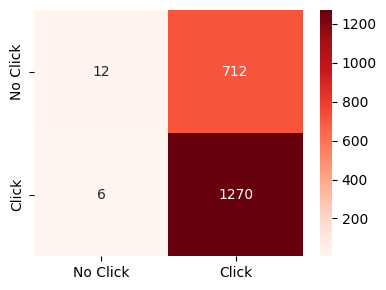

In [45]:
# Modello Decision Tree 2
dt_model2 = tree.DecisionTreeClassifier()
dt_model2.fit(X_train, y_train)
y_pred_dt = dt_model2.predict(X_test)
print("\nPerformance Decision Tree: \n")
print(classification_report(y_test, y_pred_dt))
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
cm = confusion_matrix(y_test, y_pred_dt)
print("\n Confusion Matrix Decision Tree (dt_model2):\n")
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=['No Click', 'Click'], yticklabels=['No Click', 'Click'])
plt.tight_layout()
plt.show()

* Sia l'SVM che il DT hanno lo stesso problema: predicono quasi sempre click=1.
* Il Decision Tree riconosce leggermente meglio la classe No Click (12 corretti rispetto a 0 dell'SVM), ma è ancora molto squilibrato.

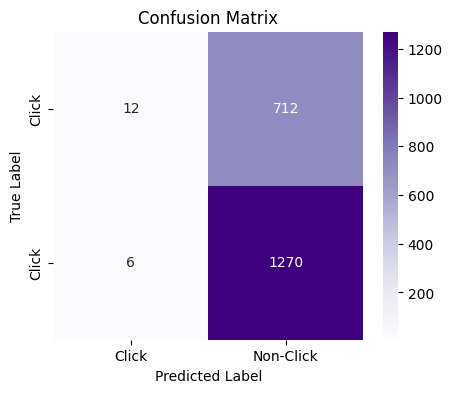

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.02      0.03       724
           1       0.64      1.00      0.78      1276

    accuracy                           0.64      2000
   macro avg       0.65      0.51      0.41      2000
weighted avg       0.65      0.64      0.51      2000


Performance Random Forest: 

Accuracy: 0.641
Precision: 0.6407669021190716
Recall: 0.9952978056426333


In [46]:
# Implementazione Random Forest (AI)

rf = RandomForestClassifier(n_estimators=100, random_state=rand_state)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=["Click", "Non-Click"], yticklabels=["Click", "Click"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("\nPerformance Random Forest: \n")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))

Il Random Forest non sta funzionando correttamente perché sta prevedendo quasi sempre click=1.

# **CONCLUSIONI**

### L'utilizzo di codici e studio grafici ci hanno aiutato a trarre le seguenti conclusioni e considerazioni:
1. Meno del 10% delle osservazioni ha informazioni complete
2. Nessuna delle variabili predittive prese singolarmente sembra avere una forte correlazione con la variabile target
3. I modelli basati su Decision Tree sembrano performare meglio di quelli basati su SVM
4. I 7 modelli testati si equivalgono in termini di velocità, restituendo risultati in meno di 3 secondi ciascuno.
5. Il modello più performante **Random Forest** (della prima soluzione) ha un'accuratezza del 76% circa ed è allenato con 480 osservazioni, quindi potrebbe essere a rischio overfitting. Data la scarsa numerosità di osservazioni, sarebbe utile avere un secondo dataset per valutare le performance
6. I modelli della **Soluzione 2** producono risultati insoddisfacenti, in quanto non riescono a identificare i Non-Click. Le variabili escluse potrebbero aver causato una perdita di informazioni troppo elevata.